# Series Temporales

In [102]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

from statsmodels.tsa.arima.model import ARIMA

import joblib

In [103]:
df = pd.read_csv('/workspaces/IgnacioSabinoG-IntroML/data/raw/sales.csv', sep= ',')
df

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633
...,...,...
361,2023-08-30 17:10:08.079328,989.600354
362,2023-08-31 17:10:08.079328,994.987326
363,2023-09-01 17:10:08.079328,995.814415
364,2023-09-02 17:10:08.079328,997.350214


La serie corresponde a un año completo desde el 3 de septiembre de 2022 hasta incluso el 3 de septiembre de 2023.

Es una serie temporal univariante (una sola variable medida en el tiempo), por lo que el tensor de rango 1 (vector).

Es un tensor de forma (366,), lo que indica que tenemos 366 puntos de datos en una sola dimensión temporal.

Como a primera vista parece que el dato siguiente siempre es mayor se hará una verificación de si los datos son de ventas acumuladas.

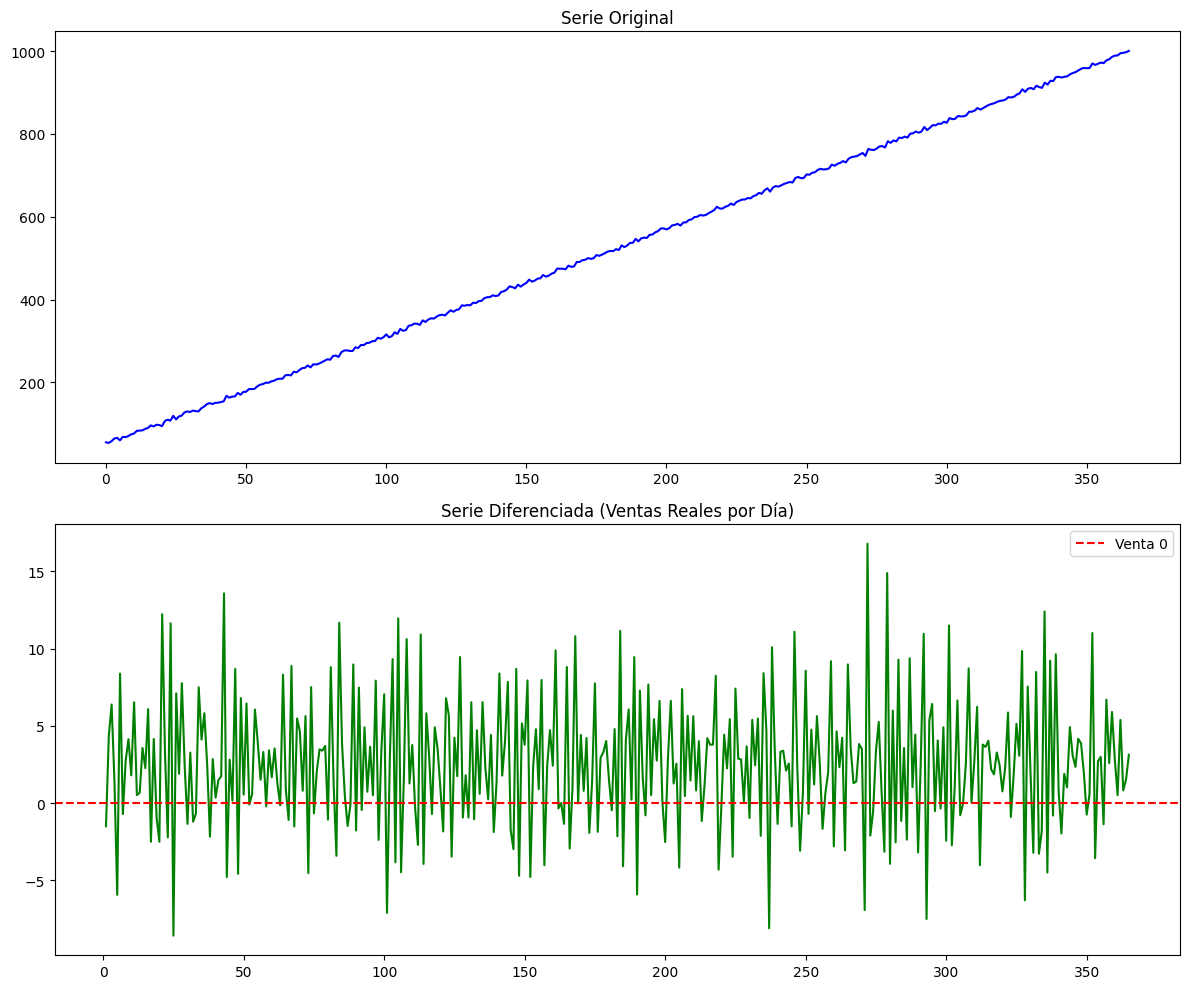

In [104]:
# Calcular la diferencia entre el día actual y el anterior
df['sales_diff'] = df['sales'].diff()

# Graficar ambas para comparar
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

ax[0].plot(df['sales'], color='blue')
ax[0].set_title('Serie Original')

ax[1].plot(df['sales_diff'], color='green')
ax[1].set_title('Serie Diferenciada (Ventas Reales por Día)')
ax[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Venta 0')
ax[1].legend()

plt.tight_layout()
plt.show()

In [105]:
df['sales_diff']

0           NaN
1     -1.488946
2      4.338482
3      6.389205
4      1.482734
         ...   
361    0.518681
362    5.386972
363    0.827090
364    1.535798
365    3.132571
Name: sales_diff, Length: 366, dtype: float64

In [106]:
df['sales_diff'].describe()

count    365.000000
mean       2.589563
std        4.258554
min       -8.569621
25%       -0.344468
50%        2.454115
75%        5.256825
max       16.788255
Name: sales_diff, dtype: float64

Debido a la marcada linealidad de los datos sospeché que podría trarse de valores acumulados de ventas en vez de ventas diarias realmente, pero como en la diferencia con el día anterior dan valores negativos en algunas fechas, se descarta esta posibilidad.

Por lo tanto se trata de una serie con una tendencia lineal muy fuerte (como un crecimiento constante programado), pero con fluctuaciones que a veces superan ese crecimiento, llevando el valor diario por debajo del día anterior.

El segundo gráfico muestra esa clara tendencia de aumento con respecto al día anterior con promedio de 2.6, un mínimo de -8.6 y un máximo de 16.8.

Se observa que no es estacionaria. Al tener una tendencia tan marcada hacia arriba, la media cambia constantemente. Una serie estacionaria debería oscilar siempre alrededor de un mismo valor.

Existe una marcada variabilidad o ruido muy alto. El hecho de que la diferencia pase de -1.48 a 4.33 y luego a 6.38 indica que hay mucho "ruido" aleatorio superpuesto a la tendencia lineal. No se ve un patrón cíclico claro, sino saltos irregulares.

## Descomposición

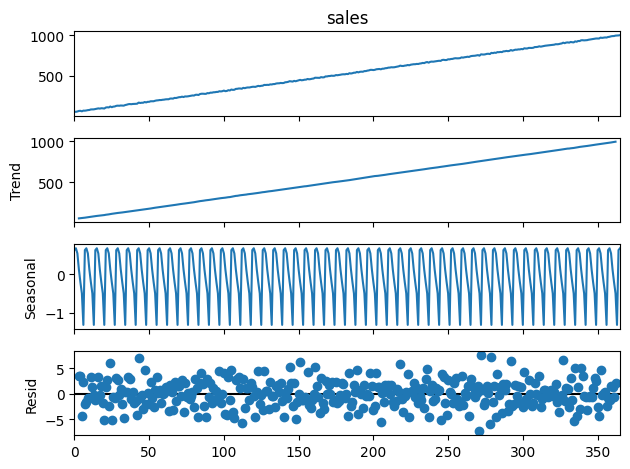

In [107]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Descomposición (asumiendo periodicidad, por ejemplo 12 si son meses o 7 si son días)
res = seasonal_decompose(df['sales'], model='additive', period=7) 

# Graficar tendencia, estacionalidad y residuo
res.plot()
plt.show()

El análisis de tendencia y estacionalidad confirma las apreciaciones iniciales.

Se notan unos 30 ciclos en los 366 datos. lo que representaría ciclos de unos 12 días.

<Figure size 1000x500 with 0 Axes>

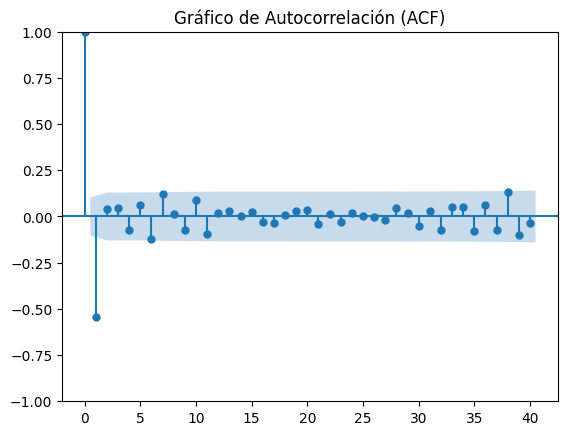

In [108]:
from statsmodels.graphics.tsaplots import plot_acf

# Usamos la serie diferenciada para quitar la tendencia y ver solo el ciclo
plt.figure(figsize=(10, 5))
plot_acf(df['sales'].diff().dropna(), lags=40) 
plt.title('Gráfico de Autocorrelación (ACF)')
plt.show()

7 y 8 días son los valores más interesantes para tomar como ciclidad. Los valores más bajos mostrarían una muy alta frecuencia no muy útil para la predicción.

In [109]:
from scipy.signal import periodogram

f, Pxx_den = periodogram(df['sales'].diff().dropna())

# El periodo es 1 / frecuencia
periodo_estimado = 1 / f[np.argmax(Pxx_den)]
print(f"El ciclo dominante sugerido es de aproximadamente: {periodo_estimado:.2f} días")

El ciclo dominante sugerido es de aproximadamente: 2.55 días


# Entrenamiento y Predicción

Para trabajar con modelos ARIMA, necesitamos que la serie sea estacionaria.

Como vimos que la serie tiene una tendencia lineal muy fuerte, el modelo ARIMA se encargará de "diferenciar" los datos automáticamente si configuramos el parámetro d.

In [110]:
# Limpieza extrema de fechas
# Convertimos y eliminamos cualquier fila que no tenga fecha válida
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

# Eliminar la información de horas/minutos para que sean solo días
# Esto evita que asfreq('D') falle por micro-diferencias de segundos
df['date'] = df['date'].dt.normalize()

# Establecer índice y eliminar duplicados (por si acaso)
df = df.set_index('date')
df = df[~df.index.duplicated(keep='first')]

# Ahora sí, asegurar la frecuencia diaria
df = df.asfreq('D')
df['sales'] = df['sales'].ffill()

# Verificación (Debe imprimir 366)
print(f"Total de días: {len(df)}")

# División Train/Test
train_size = int(len(df) * 0.8)
train, test = df['sales'][:train_size], df['sales'][train_size:]

Total de días: 366


In [111]:
# Entrenamos con order=(1,1,1)
# d=1 diferencia los datos automáticamente para hacerlos estacionarios
model_arima = ARIMA(train, order=(1, 1, 1))
model_res = model_arima.fit()

print(model_res.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  292
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -838.546
Date:                Thu, 16 Apr 2026   AIC                           1683.092
Time:                        20:38:07   BIC                           1694.112
Sample:                    09-03-2022   HQIC                          1687.506
                         - 06-21-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.001   1863.304      0.000       0.999       1.001
ma.L1         -0.9996      0.473     -2.111      0.035      -1.928      -0.072
sigma2        18.3520      8.857      2.072      0.0

RMSE: 4.07


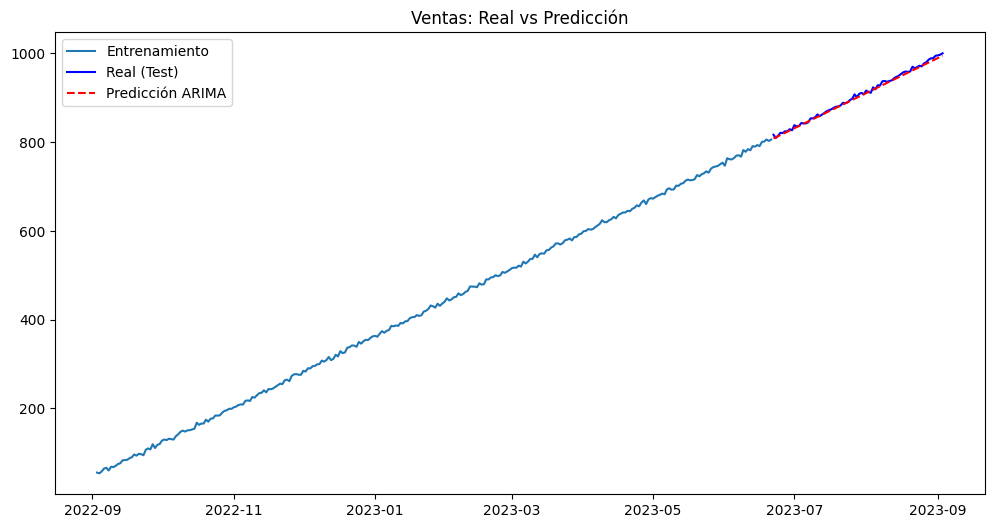

In [112]:
# Predicción para el tamaño del conjunto de test
# forecast() devuelve los valores directamente en el horizonte temporal de test
predictions = model_res.forecast(steps=len(test))

# Calcular error
rmse = np.sqrt(mean_squared_error(test, predictions))
print(f"RMSE: {rmse:.2f}")

# Gráfico final ordenado
plt.figure(figsize=(12, 6))
plt.plot(train, label='Entrenamiento')
plt.plot(test, label='Real (Test)', color='blue')
plt.plot(test.index, predictions, label='Predicción ARIMA', color='red', linestyle='--')
plt.title('Ventas: Real vs Predicción')
plt.legend()
plt.show()

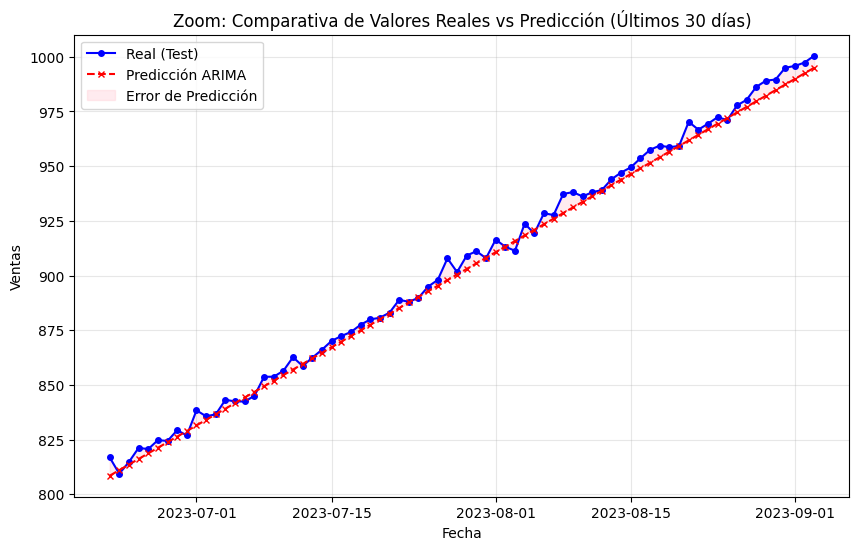

In [113]:
# 1. Crear el gráfico de comparación (Zoom en el set de prueba)
plt.figure(figsize=(10, 6))

# Dibujamos los valores reales del conjunto de test
plt.plot(test.index, test, label='Real (Test)', color='blue', marker='o', markersize=4)

# Dibujamos las predicciones del ARIMA
plt.plot(test.index, predictions, label='Predicción ARIMA', color='red', linestyle='--', marker='x', markersize=4)

# Opcional: Sombrear el área entre las dos líneas para ver el error
plt.fill_between(test.index, test, predictions, color='pink', alpha=0.3, label='Error de Predicción')

plt.title('Zoom: Comparativa de Valores Reales vs Predicción (Últimos 30 días)')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Modelo para tomar en cuenta la fuerte ciclicidad

In [114]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Definimos el orden estacional (P, D, Q, s)
# s=12 es la periodicidad que encontraste
model_sarima = SARIMAX(train, 
                       order=(1, 1, 1), 
                       seasonal_order=(1, 1, 1, 7)) 

model_res = model_sarima.fit(disp=False)

# Paso 4: Nueva predicción
predictions_seasonal = model_res.forecast(steps=len(test))

# Comparación de RMSE
rmse_s = np.sqrt(mean_squared_error(test, predictions_seasonal))
print(f"Nuevo RMSE con Estacionalidad: {rmse_s:.2f}")

Nuevo RMSE con Estacionalidad: 2.84


### El error con estacionalidad bajó a 2.84 de 4.7 que estaba antes.

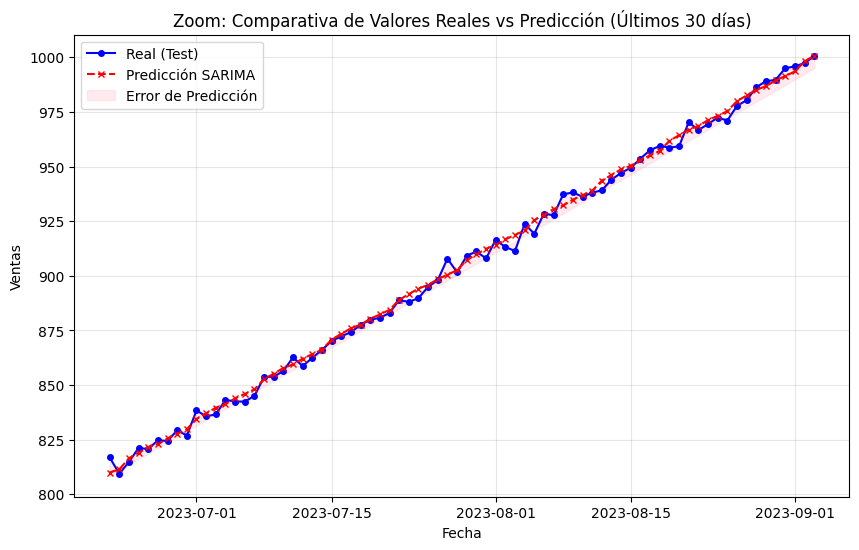

In [115]:
# 1. Crear el gráfico de comparación (Zoom en el set de prueba)
plt.figure(figsize=(10, 6))

# Dibujamos los valores reales del conjunto de test
plt.plot(test.index, test, label='Real (Test)', color='blue', marker='o', markersize=4)

# Dibujamos las predicciones del ARIMA
plt.plot(test.index, predictions_seasonal, label='Predicción SARIMA', color='red', linestyle='--', marker='x', markersize=4)

# Opcional: Sombrear el área entre las dos líneas para ver el error
plt.fill_between(test.index, test, predictions, color='pink', alpha=0.3, label='Error de Predicción')

plt.title('Zoom: Comparativa de Valores Reales vs Predicción (Últimos 30 días)')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Guardar el modelo

In [116]:
joblib.dump(model_sarima, 'arima_model_sales.joblib')
print("Modelo SARIMA guardado con éxito.")

Modelo SARIMA guardado con éxito.
